In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from SOM import SOM

In [42]:
data = pd.read_csv('./data/iris81_trn.csv')
data = data.values.astype(float)
X = data[:, :-3]  # Todas las columnas excepto las 3 últimas
y = np.argmax(data[:, -3:], axis=1)  # La clase es el índice del valor máximo en las últimas 3 columnas


In [48]:
def graficar_som(X, w, map_size):
    ganadoras = []
    for x in X: 
        distancias = np.linalg.norm(w - x, axis=2) 
        ganadora_index = np.unravel_index(np.argmin(distancias), distancias.shape)
        ganadoras.append(ganadora_index)
    ganadoras = np.array(ganadoras)

    # Asignar un color a cada neurona ganadora
    colores = ganadoras[:,0] * map_size + ganadoras[:,1]
    plt.figure(figsize=(8,8))
    # Graficar los datos de entrenamiento coloreados por neurona ganadora
    plt.scatter(X[:,0], X[:,2], c=colores, cmap='tab20', marker='x', label='Datos')

    # Graficar los centroides
    for i in range(map_size):
        for j in range(map_size):
            plt.scatter(w[i,j,0], w[i,j,1], marker='o', color='black', s=100, edgecolor='white', label='Centroide' if (i==0 and j==0) else "")
            # Unir con vecinos (derecha y abajo)
            if i + 1 < map_size:
                plt.plot([w[i,j,0], w[i+1,j,0]], [w[i,j,1], w[i+1,j,1]], color='blue', linewidth=1)
            if j + 1 < map_size:
                plt.plot([w[i,j,0], w[i,j+1,0]], [w[i,j,1], w[i,j+1,1]], color='blue', linewidth=1)
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.title('Scatter de los datos X')
    plt.legend()
    plt.show()

In [46]:

map_size = 5
# Inicializamos los pesos
som = SOM(map_size)

som.fit(X, 500, [0.9, 0.9], [3, 3])
som.fit(X, 1000, [0.9, 0.1], [3, 1])
som.fit(X, 1000, [0.01, 0.01], [0, 0])


El entrenamiento finalizó en la época 499 en 2.22 segundos.
El entrenamiento finalizó en la época 999 en 3.16 segundos.
El entrenamiento finalizó en la época 999 en 0.82 segundos.


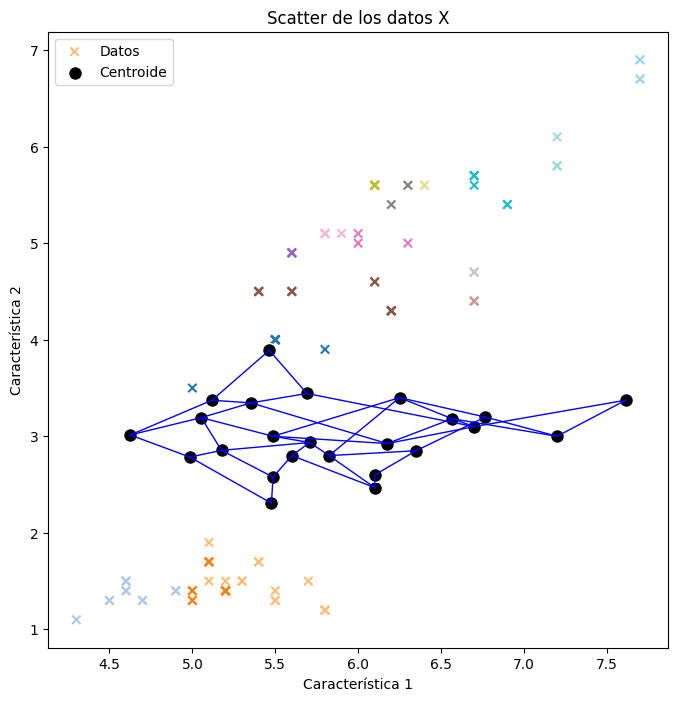

In [49]:
graficar_som(X, som.w, map_size)